In [11]:
# ============================================================
# CNN TRAINING IN JUPYTER NOTEBOOK (LOCAL WINDOWS)
# Dataset structure:
# C:\Users\yadav\Downloads\BrainTumorProject\final_merged_dataset
# ├── Training
# └── Testing
# ============================================================

# If TensorFlow is not installed, run this once:
# import sys
# !{sys.executable} -m pip install tensorflow matplotlib scikit-learn seaborn

import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ------------------------------------------------------------
# Dataset Path (Windows)
# ------------------------------------------------------------
DATASET_DIR = (
    r"C:\Users\yadav\Downloads\BrainTumorProject\final_merged_dataset"
)

TRAIN_DIR = os.path.join(DATASET_DIR, "Training")
TEST_DIR  = os.path.join(DATASET_DIR, "Testing")

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 8
SEED = 42
DROPOUT_RATE = 0.2

MODEL_DIR = r"C:\Users\yadav\Downloads\BrainTumorProject\model_output"
os.makedirs(MODEL_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load Datasets
# ------------------------------------------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

# ------------------------------------------------------------
# Optimize Data Pipeline
# ------------------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# ------------------------------------------------------------
# Build CNN Model
# Filters = 16, 32, 64, 128
# Dropout = 0.2
# ------------------------------------------------------------
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(DROPOUT_RATE),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# To use SGD instead:
# optimizer = tf.keras.optimizers.SGD(
#     learning_rate=1e-4,
#     momentum=0.9
# )

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ------------------------------------------------------------
# Learning Rate Schedule
# Epoch 0-5: 1e-4
# Epoch 6-7: 5e-5
# ------------------------------------------------------------
def lr_schedule(epoch, lr):
    if epoch < 6:
        return 1e-4
    elif epoch < 8:
        return 5e-5
    else:
        return 1e-5

lr_callback = LearningRateScheduler(
    lr_schedule,
    verbose=1
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------
callbacks = [
    lr_callback,
    EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "best_model.keras"),
        monitor="val_accuracy",
        save_best_only=True
    )
]

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    shuffle=True,
    callbacks=callbacks
)

# ------------------------------------------------------------
# Evaluate Model
# ------------------------------------------------------------
loss, accuracy = model.evaluate(test_ds)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# ------------------------------------------------------------
# Save Final Model
# ------------------------------------------------------------
final_model_path = os.path.join(
    MODEL_DIR,
    "proposed_cnn_model.keras"
)

model.save(final_model_path)

print("Model saved successfully.")
print("Saved to:", final_model_path)

Found 14345 files belonging to 4 classes.
Found 2112 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,521,252 (24.88 MB)

 Trainable params: 6,521,252 (24.88 MB)

 Non-trainable params: 0 (0.00 B)


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/8
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 304s 167ms/step - accuracy: 0.7446 - loss: 0.6030 - val_accuracy: 0.7685 - val_loss: 0.7522 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0001.
Epoch 2/8
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 317s 156ms/step - accuracy: 0.8758 - loss: 0.3261 - val_accuracy: 0.8698 - val_loss: 0.5944 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0001.
Epoch 3/8
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 273s 152ms/step - accuracy: 0.9275 - loss: 0.1972 - val_accuracy: 0.9119 - val_loss: 0.5012 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0001.
Epoch 4/8
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 360s 173ms/step - accuracy: 0.9532 - loss: 0.1278 - val_accuracy: 0.9015 - val_loss: 0.5738 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 0.0001.
Epoch 5/8
1794/1794 ━━━━━━━━━━━

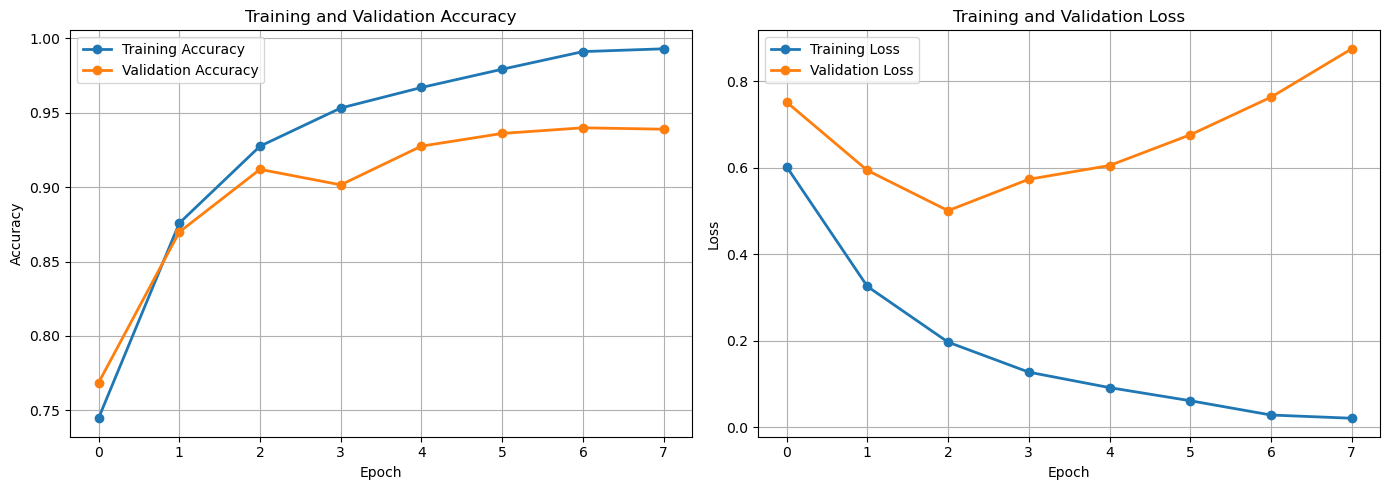

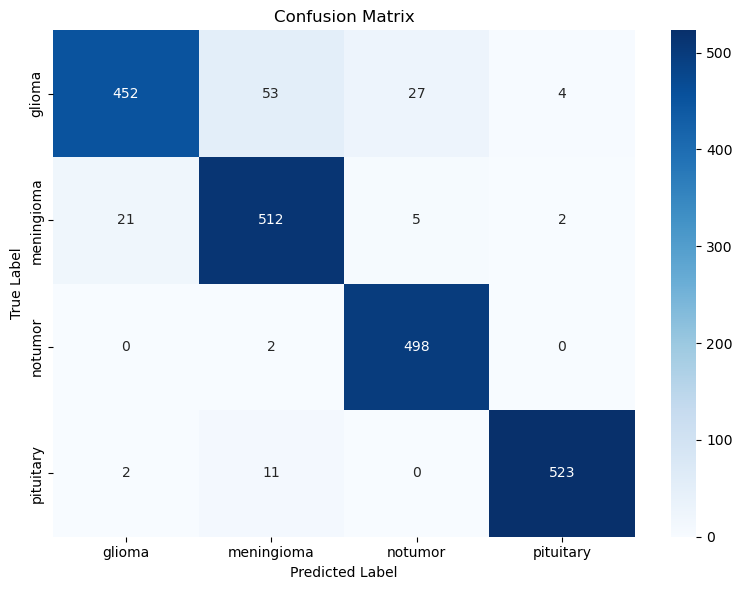


Classification Report:

              precision    recall  f1-score   support

      glioma     0.9516    0.8433    0.8942       536
  meningioma     0.8858    0.9481    0.9159       540
     notumor     0.9396    0.9960    0.9670       500
   pituitary     0.9887    0.9757    0.9822       536

    accuracy                         0.9399      2112
   macro avg     0.9414    0.9408    0.9398      2112
weighted avg     0.9413    0.9399    0.9393      2112



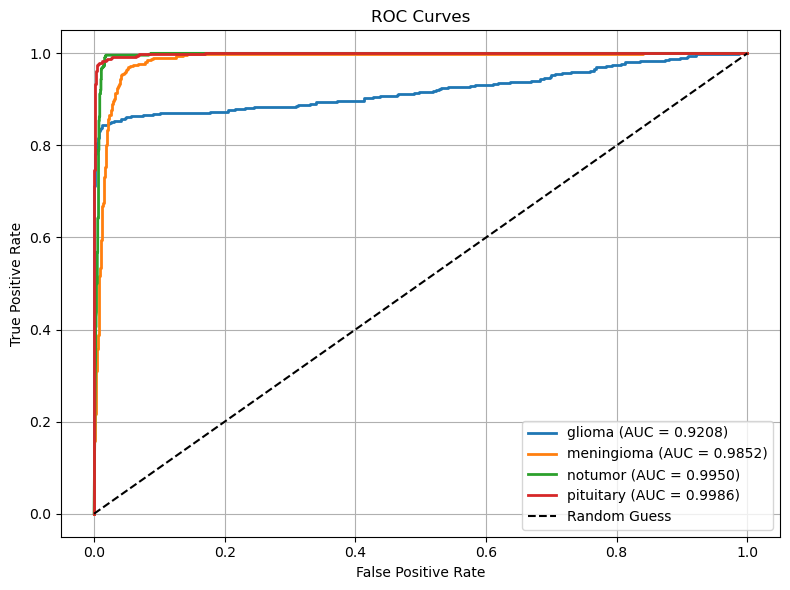

In [12]:
# ============================================================
# EVALUATION PLOTS FOR JUPYTER NOTEBOOK
# - Training Accuracy / Validation Accuracy
# - Training Loss / Validation Loss
# - Confusion Matrix
# - Classification Report
# - ROC Curves (AUC)
#
# Run this cell AFTER model.fit(...)
# Required variables:
#   history, model, test_ds, class_names
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------
# 1. TRAINING & VALIDATION ACCURACY / LOSS GRAPHS
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], marker="o", linewidth=2,
         label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", linewidth=2,
         label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], marker="o", linewidth=2,
         label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", linewidth=2,
         label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. COLLECT PREDICTIONS
# ------------------------------------------------------------
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    true = np.argmax(labels.numpy(), axis=1)

    y_true.extend(true)
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ------------------------------------------------------------
# 3. CONFUSION MATRIX
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. CLASSIFICATION REPORT
# ------------------------------------------------------------
print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# ------------------------------------------------------------
# 5. ROC CURVES (ONE-VS-REST)
# ------------------------------------------------------------
num_classes = len(class_names)

# Convert true labels to one-hot format
y_true_bin = label_binarize(
    y_true,
    classes=list(range(num_classes))
)

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc:.4f})"
    )

# Random baseline
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()